<a href="https://colab.research.google.com/github/Vaibhav030406/AI-CHATBOT-BY-VAIBHAV/blob/main/video_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║      CELL 1 — Setup, Kaggle Auth & Dataset Download         ║
# ╚══════════════════════════════════════════════════════════════╝

# ─── 1a. Mount Google Drive ───────────────────────────────────
from google.colab import drive, files
drive.mount('/content/drive')

# ─── 1b. Upload kaggle.json ───────────────────────────────────
print("📂 Upload your kaggle.json file:")
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle credentials configured.")

# ─── 1c. Install libraries ────────────────────────────────────
!pip install -q kaggle opencv-python-headless albumentations optuna timm
print("✅ Libraries installed.")

# ─── 1d. Download Dataset ─────────────────────────────────────
print("\n⬇️  Downloading Real Life Violence Dataset (~1 GB)...")
os.makedirs('/content/violence_data', exist_ok=True)

os.system(
    'kaggle datasets download '
    '-d mohamedmustafa/real-life-violence-situations-dataset '
    '--unzip -p /content/violence_data'
)
print("✅ Download complete.")

# ─── 1e. Verify Structure ─────────────────────────────────────
from pathlib import Path

DATA_DIR = Path('/content/violence_data')

print("\n📁 Folder structure:")
for item in sorted(DATA_DIR.rglob('*'))[:10]:
    print(' ', item)

print("\n📊 File counts:")
for label in ['Violence', 'NonViolence']:
    folder = list(DATA_DIR.rglob(label))
    if folder:
        count = len(list(folder[0].glob('*.mp4')))
        print(f"  {label}: {count} videos")

# ─── 1f. Core Imports ─────────────────────────────────────────
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# ── PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# ── Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, log_loss,
                             accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix)
# ── Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ─── 1g. Global Config ────────────────────────────────────────
SEED       = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR   = Path('/content/violence_data')
DRIVE_DIR  = Path('/content/drive/MyDrive/Violence_Assignment')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = 224    # Frame resize
N_FRAMES   = 16     # Frames sampled per video
BATCH_SIZE = 8      # Lower because each sample = 16 frames
EPOCHS     = 10
LR         = 1e-4

print(f"\n{'='*45}")
print(f"✅ Everything ready!")
print(f"🖥️  Device     : {DEVICE}")
print(f"📁 Data dir   : {DATA_DIR}")
print(f"💾 Drive dir  : {DRIVE_DIR}")
print(f"🎞️  Frames/vid : {N_FRAMES}")
print(f"📦 Batch size : {BATCH_SIZE}")
print(f"{'='*45}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured.
✅ Libraries installed.

⬇️  Downloading Real Life Violence Dataset (~1 GB)...
✅ Download complete.

📁 Folder structure:
  /content/violence_data/Real Life Violence Dataset
  /content/violence_data/Real Life Violence Dataset/NonViolence
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_1.mp4
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_10.mp4
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_100.mp4
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_1000.mp4
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_101.mp4
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_102.mp4
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_103.mp4
  /content/violence_data/Real Life Violence Dataset/NonViolence/NV_104.mp4

📊 File counts:
  Violence: 1000 videos
  NonViolence: 951 videos

✅ Everything ready!
🖥️  Device  

📊 DATASET OVERVIEW
Total videos        : 1951
Violence videos     : 1000
NonViolence videos  : 951
Class balance       : 51.26% Violence

                                            filepath  label   class_name
0  /content/violence_data/Real Life Violence Data...      0  NonViolence
1  /content/violence_data/Real Life Violence Data...      0  NonViolence
2  /content/violence_data/Real Life Violence Data...      0  NonViolence
3  /content/violence_data/Real Life Violence Data...      0  NonViolence
4  /content/violence_data/Real Life Violence Data...      1     Violence
5  /content/violence_data/Real Life Violence Data...      1     Violence
6  /content/violence_data/Real Life Violence Data...      0  NonViolence
7  /content/violence_data/Real Life Violence Data...      1     Violence


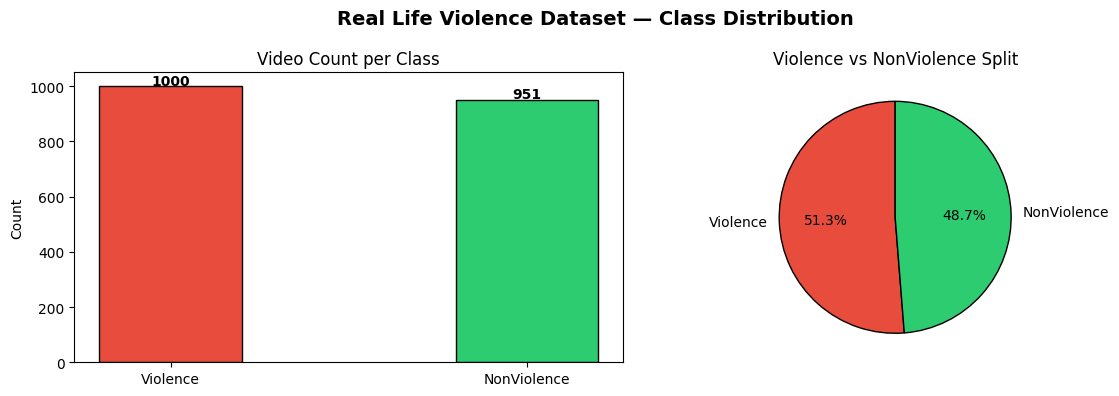

💾 Saved to Drive.

🎞️  Extracting sample frames...


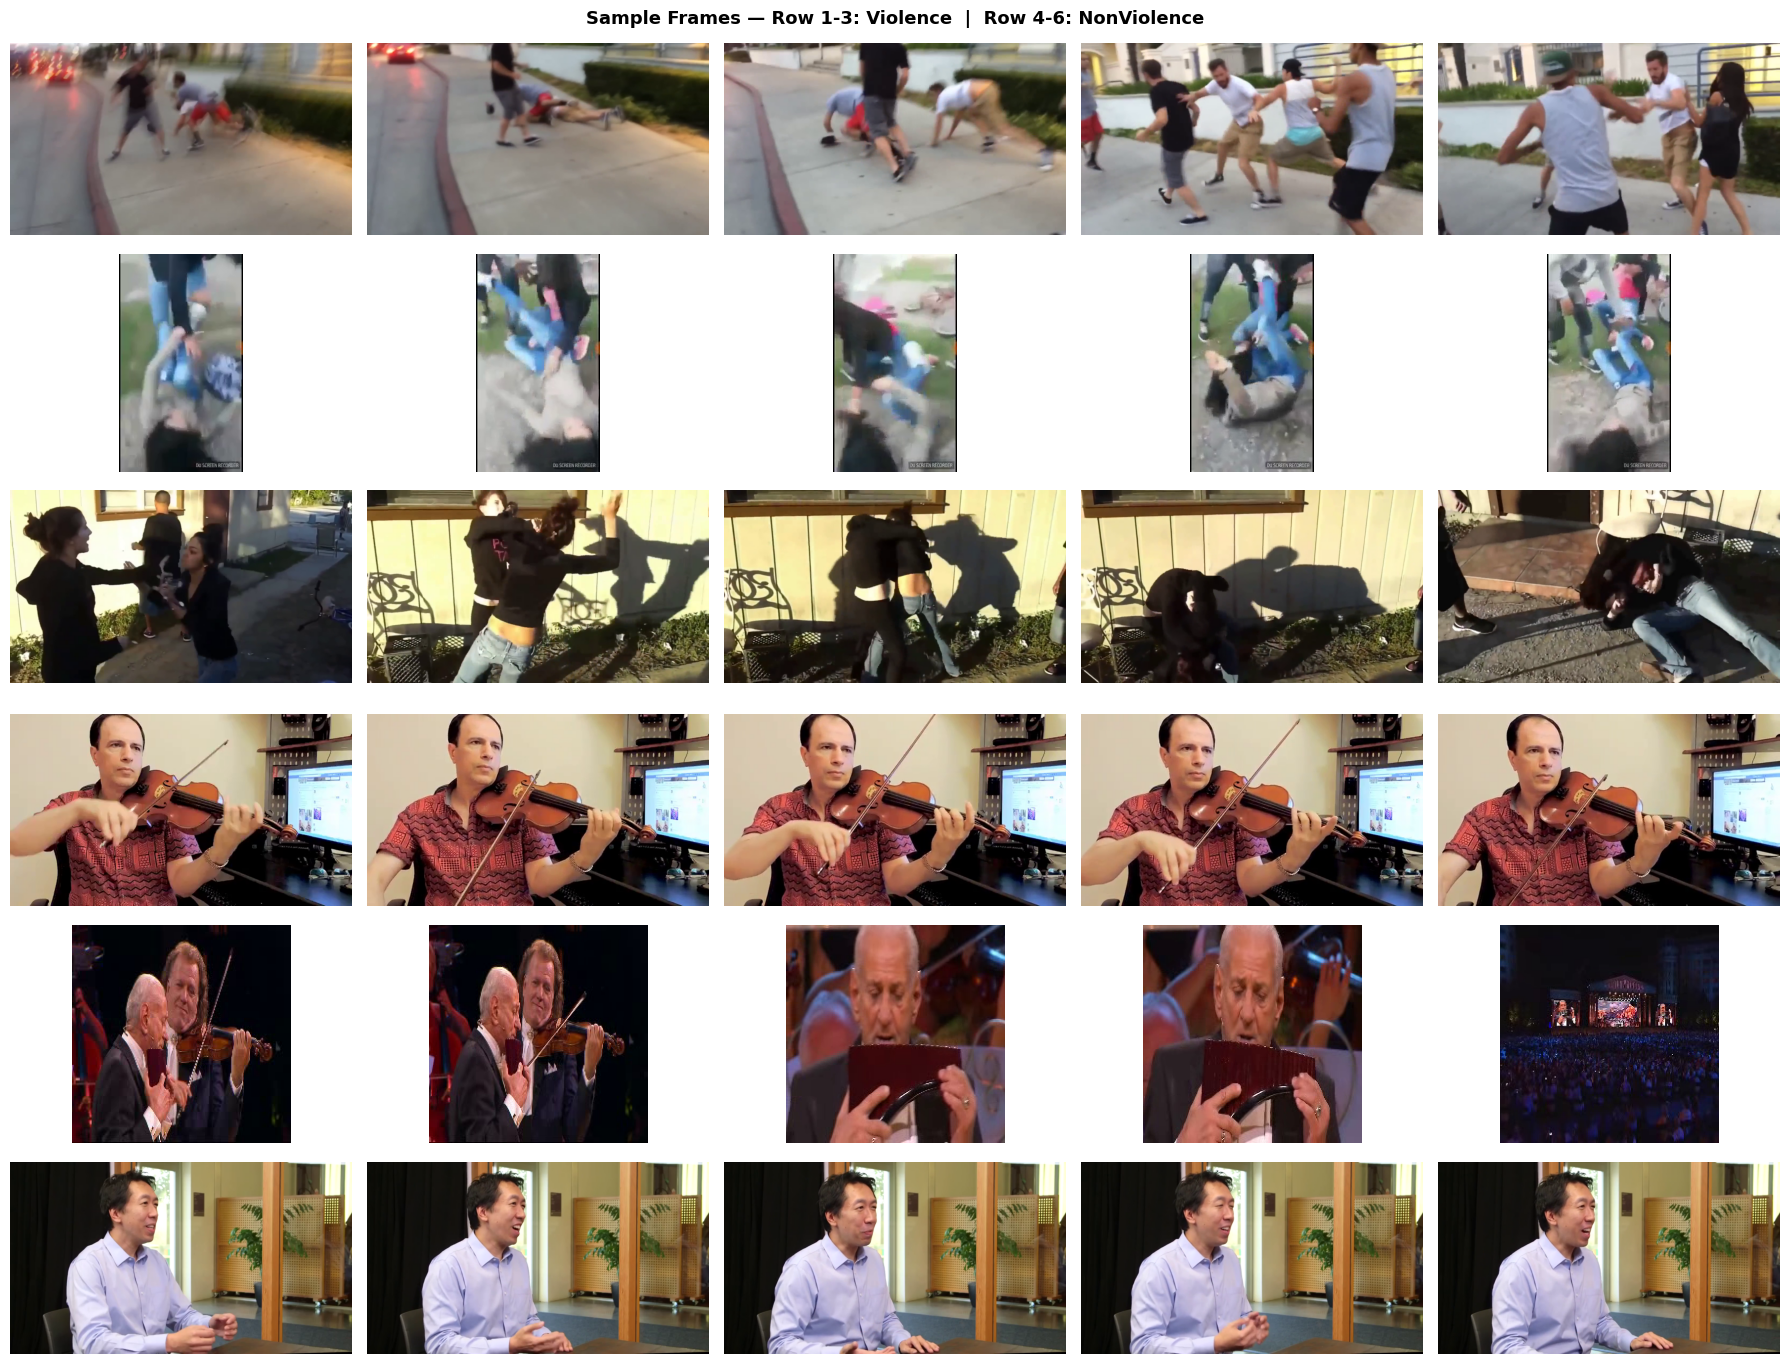

💾 Sample frames saved to Drive.

⏱️  Computing video stats (sample of 50 videos)...


100%|██████████| 50/50 [00:00<00:00, 208.35it/s]


📹 Video Statistics:
         fps  frames  duration_sec    width   height
count  50.00   50.00         50.00    50.00    50.00
mean   27.23  131.48          4.84   578.12   433.32
std     2.94   20.95          0.60   467.15   237.42
min    21.00   86.00          3.40   202.00   224.00
25%    25.00  117.75          4.62   224.00   224.00
50%    29.00  125.00          5.00   406.00   360.00
75%    30.00  149.25          5.00   694.00   660.50
max    30.00  177.00          6.31  1920.00  1080.00

  Avg duration  : 4.8 sec
  Avg FPS       : 27.2
  Avg frames    : 131
  Common res    : 224x224

✅ EDA complete! Ready for Cell 3 — Preprocessing & Dataset Class.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 2 — EDA & Dataset Analysis                     ║
# ╚══════════════════════════════════════════════════════════════╝

# ─── 2a. Fix DATA_DIR to actual subfolder ─────────────────────
DATA_DIR = Path('/content/violence_data/Real Life Violence Dataset')

VIOLENCE_DIR    = DATA_DIR / 'Violence'
NONVIOLENCE_DIR = DATA_DIR / 'NonViolence'

# ─── 2b. Build DataFrame ──────────────────────────────────────
violence_files    = [(str(f), 1, 'Violence')
                     for f in sorted(VIOLENCE_DIR.glob('*.mp4'))]
nonviolence_files = [(str(f), 0, 'NonViolence')
                     for f in sorted(NONVIOLENCE_DIR.glob('*.mp4'))]

df = pd.DataFrame(violence_files + nonviolence_files,
                  columns=['filepath', 'label', 'class_name'])
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total videos        : {len(df)}")
print(f"Violence videos     : {(df['label'] == 1).sum()}")
print(f"NonViolence videos  : {(df['label'] == 0).sum()}")
print(f"Class balance       : {(df['label']==1).mean():.2%} Violence")
print()
print(df.head(8))

# ─── 2c. Class Distribution Plot ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Real Life Violence Dataset — Class Distribution',
             fontsize=14, fontweight='bold')

counts = df['class_name'].value_counts()
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(counts.index, counts.values,
            color=colors, edgecolor='black', width=0.4)
axes[0].set_title('Video Count per Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index,
            colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Violence vs NonViolence Split')

plt.tight_layout()
plt.savefig(str(DRIVE_DIR / 'eda_class_distribution.png'), dpi=150)
plt.show()
print("💾 Saved to Drive.")

# ─── 2d. Frame Extractor ──────────────────────────────────────
def extract_frames(video_path, n_frames=5):
    """Extract n evenly spaced frames from a video."""
    cap    = cv2.VideoCapture(video_path)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs   = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

# ─── 2e. Sample Frame Viewer ──────────────────────────────────
print("\n🎞️  Extracting sample frames...")

v_samples  = df[df['label'] == 1]['filepath'].sample(3, random_state=SEED).tolist()
nv_samples = df[df['label'] == 0]['filepath'].sample(3, random_state=SEED).tolist()

fig, axes = plt.subplots(6, 5, figsize=(18, 14))
fig.suptitle('Sample Frames — Row 1-3: Violence  |  Row 4-6: NonViolence',
             fontsize=13, fontweight='bold')

for row, vpath in enumerate(v_samples):
    frames = extract_frames(vpath, n_frames=5)
    for col, frame in enumerate(frames):
        axes[row, col].imshow(frame)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel('Violence', color='red',
                                       fontsize=10, fontweight='bold')

for row, nvpath in enumerate(nv_samples):
    frames = extract_frames(nvpath, n_frames=5)
    for col, frame in enumerate(frames):
        axes[row + 3, col].imshow(frame)
        axes[row + 3, col].axis('off')
        if col == 0:
            axes[row + 3, col].set_ylabel('NonViolence', color='green',
                                           fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(str(DRIVE_DIR / 'eda_sample_frames.png'), dpi=150)
plt.show()
print("💾 Sample frames saved to Drive.")

# ─── 2f. Video Stats ──────────────────────────────────────────
def get_video_stats(path):
    cap      = cv2.VideoCapture(path)
    fps      = cap.get(cv2.CAP_PROP_FPS)
    total    = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = round(total / fps, 2) if fps > 0 else 0
    cap.release()
    return {'fps': round(fps, 1), 'frames': int(total),
            'duration_sec': duration, 'width': width, 'height': height}

print("\n⏱️  Computing video stats (sample of 50 videos)...")
sample_paths = df['filepath'].sample(50, random_state=SEED).tolist()
stats        = [get_video_stats(p) for p in tqdm(sample_paths)]
stats_df     = pd.DataFrame(stats)

print("\n📹 Video Statistics:")
print(stats_df.describe().round(2))
print(f"\n  Avg duration  : {stats_df['duration_sec'].mean():.1f} sec")
print(f"  Avg FPS       : {stats_df['fps'].mean():.1f}")
print(f"  Avg frames    : {stats_df['frames'].mean():.0f}")
print(f"  Common res    : {stats_df['width'].mode()[0]}x{stats_df['height'].mode()[0]}")

print("\n✅ EDA complete! Ready for Cell 3 — Preprocessing & Dataset Class.")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║      CELL 3 — Preprocessing & Video Dataset Class           ║
# ╚══════════════════════════════════════════════════════════════╝

# ─── 3a. Augmentation Pipelines ───────────────────────────────
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ─── 3b. VideoDataset Class ───────────────────────────────────
class VideoDataset(Dataset):
    """
    Loads a video → samples N_FRAMES evenly →
    applies transforms → returns (N_FRAMES, C, H, W)
    """
    def __init__(self, dataframe, n_frames=N_FRAMES, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.n_frames  = n_frames
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        label    = row['label']
        frames   = self._load_frames(row['filepath'])

        if self.transform:
            frames = [self.transform(image=f)['image'] for f in frames]

        video_tensor = torch.stack(frames)  # (N_FRAMES, C, H, W)
        return video_tensor, torch.tensor(label, dtype=torch.float32)

    def _load_frames(self, path):
        cap   = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        idxs  = np.linspace(0, max(total - 1, 0),
                             self.n_frames, dtype=int)
        frames = []
        for i in idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            else:
                frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            frames.append(frame)
        cap.release()

        # Safety pad — if video was shorter than N_FRAMES
        while len(frames) < self.n_frames:
            frames.append(frames[-1])
        return frames

# ─── 3c. Train / Val / Test Split (70 / 15 / 15) ─────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED,
    stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df['label']
)

print("=" * 45)
print("📂 DATA SPLITS")
print("=" * 45)
print(f"  Train : {len(train_df)} videos  "
      f"({train_df['label'].mean():.1%} Violence)")
print(f"  Val   : {len(val_df)} videos  "
      f"({val_df['label'].mean():.1%} Violence)")
print(f"  Test  : {len(test_df)} videos  "
      f"({test_df['label'].mean():.1%} Violence)")
print("=" * 45)

# ─── 3d. Datasets & DataLoaders ───────────────────────────────
train_dataset = VideoDataset(train_df, transform=train_transforms)
val_dataset   = VideoDataset(val_df,   transform=val_transforms)
test_dataset  = VideoDataset(test_df,  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,
                          pin_memory=True)

print(f"\n  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# ─── 3e. Sanity Check ─────────────────────────────────────────
print("\n🔍 Sanity check — loading one batch...")
videos, labels = next(iter(train_loader))

print(f"  Video tensor shape : {videos.shape}")
print(f"  Labels             : {labels.tolist()}")
print(f"  Dtype              : {videos.dtype}")
print(f"  Min / Max values   : {videos.min():.3f} / {videos.max():.3f}")

assert list(videos.shape) == [BATCH_SIZE, N_FRAMES, 3, IMG_SIZE, IMG_SIZE], \
    f"❌ Shape mismatch: {videos.shape}"

print(f"\n✅ Shape confirmed : "
      f"(batch={BATCH_SIZE}, frames={N_FRAMES}, "
      f"C=3, H={IMG_SIZE}, W={IMG_SIZE})")
print("✅ Preprocessing done! Ready for Cell 4 — Model Definitions.")

📂 DATA SPLITS
  Train : 1365 videos  (51.3% Violence)
  Val   : 293 videos  (51.2% Violence)
  Test  : 293 videos  (51.2% Violence)

  Train batches : 171
  Val batches   : 37
  Test batches  : 37

🔍 Sanity check — loading one batch...
  Video tensor shape : torch.Size([8, 16, 3, 224, 224])
  Labels             : [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0]
  Dtype              : torch.float32
  Min / Max values   : -2.118 / 2.640

✅ Shape confirmed : (batch=8, frames=16, C=3, H=224, W=224)
✅ Preprocessing done! Ready for Cell 4 — Model Definitions.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     CELL 4b — FINAL FIXED DATASET + DATALOADER              ║
# ╚══════════════════════════════════════════════════════════════╝

import cv2
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# ─── CONFIG ───────────────────────────────────────────────────
N_FRAMES   = 8
BATCH_SIZE = 8
EPOCHS     = 5
IMG_SIZE   = 112

# ─── TRANSFORMS ───────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ─── DATASET CLASS (FINAL FIX) ────────────────────────────────
class VideoDataset(torch.utils.data.Dataset):
    def __init__(self, df, n_frames=8, transform=None):
        self.df = df.reset_index(drop=True)
        self.n_frames = n_frames
        self.transform = transform

    def extract_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step = max(total_frames // self.n_frames, 1)

        for i in range(self.n_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        cap.release()

        while len(frames) < self.n_frames:
            frames.append(frames[-1])

        return frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        video_path = self.df.iloc[idx]['filepath']   # ✅ FIXED
        label      = self.df.iloc[idx]['label']      # ✅ FIXED

        frames = self.extract_frames(video_path)

        processed = []
        for f in frames:
            f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
            f = self.transform(f)
            processed.append(f)

        frames = torch.stack(processed)

        return frames, torch.tensor(label, dtype=torch.float32)


# ─── BUILD DATASETS ───────────────────────────────────────────
train_dataset = VideoDataset(train_df, n_frames=N_FRAMES,
                            transform=train_transforms)
val_dataset   = VideoDataset(val_df,   n_frames=N_FRAMES,
                            transform=val_transforms)

# 🔥 OPTIONAL SPEED BOOST (30% DATA)
train_dataset = Subset(train_dataset,
                      list(range(int(0.3 * len(train_dataset)))))
val_dataset   = Subset(val_dataset,
                      list(range(int(0.3 * len(val_dataset)))))

# ─── DATALOADERS ──────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print("✅ Data ready")

# ─── SANITY CHECK ─────────────────────────────────────────────
videos, labels = next(iter(train_loader))
print("✅ Shape:", videos.shape)

✅ Data ready
✅ Shape: torch.Size([8, 8, 3, 112, 112])


🧠 MODEL SUMMARY (frozen backbone)
  EfficientNet+LSTM      | Total:  6.14M | Trainable:  2.13M
  3D-CNN                 | Total:  1.20M | Trainable:  1.20M
  ConvLSTM               | Total:  0.95M | Trainable:  0.95M

🔍 Forward pass test with N_FRAMES=8...
  EfficientNet+LSTM      → torch.Size([8])
  3D-CNN                 → torch.Size([8])
  ConvLSTM               → torch.Size([8])

✅ Models ready! Now run Cell 5 — Training.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     CELL 4c — FAST MODEL                                   ║
# ╚══════════════════════════════════════════════════════════════╝

import torch.nn as nn
import torchvision.models as models

class EfficientNetLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])

        for param in self.cnn.parameters():
            param.requires_grad = False

        self.lstm = nn.LSTM(1280, 128, batch_first=True)
        self.fc   = nn.Linear(128, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        with torch.no_grad():
            x = self.cnn(x)

        x = x.view(B, T, 1280)
        x, _ = self.lstm(x)

        x = x[:, -1, :]
        return self.fc(x).squeeze(1)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetLSTM().to(DEVICE)

print("✅ Model ready on", DEVICE)

✅ Model ready on cuda


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     CELL 5 — FAST TRAINING                                 ║
# ╚══════════════════════════════════════════════════════════════╝

import torch.optim as optim
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

scaler = GradScaler()

def train_one_epoch():
    model.train()
    total_loss, preds_all, labels_all = 0, [], []

    for videos, labels in tqdm(train_loader, leave=False):
        videos = videos.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast():
            outputs = model(videos)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        preds_all.extend((preds > 0.5).astype(int))
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(train_loader), acc


def evaluate():
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for videos, labels in val_loader:
            videos = videos.to(DEVICE)
            labels = labels.to(DEVICE)

            with autocast():
                outputs = model(videos)

            preds = torch.sigmoid(outputs).cpu().numpy()
            preds_all.extend((preds > 0.5).astype(int))
            labels_all.extend(labels.cpu().numpy())

    return accuracy_score(labels_all, preds_all)


print("\n🚀 TRAINING STARTED\n")

best_acc = 0

for epoch in range(EPOCHS):
    loss, train_acc = train_one_epoch()
    val_acc = evaluate()

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/content/best_model.pth")

print(f"\n✅ Best Val Accuracy: {best_acc:.4f}")


🚀 TRAINING STARTED



Epoch 1: Loss=0.6125, Train Acc=0.6895, Val Acc=0.8391


Epoch 2: Loss=0.4226, Train Acc=0.8068, Val Acc=0.9080


Epoch 3: Loss=0.3621, Train Acc=0.8460, Val Acc=0.8966


Epoch 4: Loss=0.2875, Train Acc=0.8949, Val Acc=0.9310


Epoch 5: Loss=0.3493, Train Acc=0.8778, Val Acc=0.8966

✅ Best Val Accuracy: 0.9310


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     QUICK DEMO — PREDICT ONE VIDEO                          ║
# ╚══════════════════════════════════════════════════════════════╝

import cv2

model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()

def predict_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // N_FRAMES, 1)

    for i in range(N_FRAMES):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = train_transforms(frame)
        frames.append(frame)

    cap.release()

    while len(frames) < N_FRAMES:
        frames.append(frames[-1])

    frames = torch.stack(frames).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(frames)
        prob = torch.sigmoid(output).item()

    label = "Violence 🔴" if prob > 0.5 else "Non-Violence 🟢"

    print(f"\n🎥 Prediction: {label}")
    print(f"Confidence: {prob:.4f}")

In [ ]:
# Get a NON-VIOLENCE sample
non_violence_sample = train_df[train_df['label'] == 0].iloc[0]['filepath']

print("Testing on NON-VIOLENCE video:")
predict_video(non_violence_sample)

Testing on NON-VIOLENCE video:

🎥 Prediction: Non-Violence 🟢
Confidence: 0.0450


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     GRADIO UI — VIOLENCE DETECTION                          ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install -q gradio

import gradio as gr
import torch
import cv2
import numpy as np

# ─── LOAD MODEL ───────────────────────────────────────────────
model.load_state_dict(torch.load("/content/best_model.pth", map_location=DEVICE))
model.eval()

# ─── PREDICTION FUNCTION ──────────────────────────────────────
def predict_video_gradio(video_file):
    try:
        cap = cv2.VideoCapture(video_file)
        frames = []

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step = max(total_frames // N_FRAMES, 1)

        for i in range(N_FRAMES):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = train_transforms(frame)
            frames.append(frame)

        cap.release()

        # Padding if needed
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])

        frames = torch.stack(frames).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(frames)
            prob = torch.sigmoid(output).item()

        label = "🔴 Violence" if prob > 0.5 else "🟢 Non-Violence"

        return f"{label}\nConfidence: {prob:.4f}"

    except Exception as e:
        return f"Error: {str(e)}"

# ─── GRADIO INTERFACE ─────────────────────────────────────────
iface = gr.Interface(
    fn=predict_video_gradio,
    inputs=gr.Video(label="Upload Video"),
    outputs=gr.Textbox(label="Prediction"),
    title="🚨 Violence Detection System",
    description="Upload a video to detect whether it contains violent activity."
)

# ─── LAUNCH ───────────────────────────────────────────────────
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ec769ad5752b90eb5b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
